In [2]:
import pandas as pd
df = pd.read_csv("processed_ecommerce_data.csv")
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# ADVANCED FEATURE ENGINEERING  (built strictly from raw original columns)
# Raw columns used:
#   Tenure, CityTier, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered,
#   SatisfactionScore, NumberOfAddress, Complain, OrderAmountHikeFromlastYear,
#   CouponUsed, OrderCount, DaySinceLastOrder, CashbackAmount,
#   PreferredLoginDevice, PreferredPaymentMode, Gender,
#   PreferedOrderCat, MaritalStatus
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("ADVANCED FEATURE ENGINEERING FROM RAW COLUMNS")
print("=" * 70)

df_fe = df.copy()

# ── helper: safe divide ──────────────────────────────────────────────────────
def safe_div(a, b, fill=0.0):
    return np.where(b != 0, a / b, fill)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 1 · RFM-STYLE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("\n[1] RFM-style features...")

# Recency – normalised days since last order relative to tenure
df_fe['Recency_Score']         = safe_div(df_fe['DaySinceLastOrder'],
                                          df_fe['Tenure'] + 1)

# Frequency – orders per active month
df_fe['Order_Frequency']       = safe_div(df_fe['OrderCount'],
                                          df_fe['Tenure'] + 1)

# Monetary – cashback earned per order (proxy for spend value)
df_fe['Cashback_per_Order']    = safe_div(df_fe['CashbackAmount'],
                                          df_fe['OrderCount'] + 1)

# Monetary – coupon spend per order
df_fe['Coupon_per_Order']      = safe_div(df_fe['CouponUsed'],
                                          df_fe['OrderCount'] + 1)

# Monetary – avg order amount hike per order
df_fe['AvgHike_per_Order']     = safe_div(df_fe['OrderAmountHikeFromlastYear'],
                                          df_fe['OrderCount'] + 1)

# Recency bins  (higher bin number = longer away = higher risk)
df_fe['Recency_Bin'] = pd.cut(
    df_fe['DaySinceLastOrder'],
    bins=[-1, 5, 15, 30, 9999],
    labels=[0, 1, 2, 3]
).astype(float)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 2 · TENURE / LIFECYCLE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[2] Tenure / lifecycle features...")

# Lifecycle stage: 0=New(≤1m), 1=Growing(2-6m), 2=Mature(7-12m), 3=Loyal(>12m)
df_fe['Lifecycle_Stage'] = pd.cut(
    df_fe['Tenure'],
    bins=[-1, 1, 6, 12, 9999],
    labels=[0, 1, 2, 3]
).astype(float)

# Squared tenure – captures accelerating loyalty effect
df_fe['Tenure_sq']             = df_fe['Tenure'] ** 2

# App engagement density (hours per active month)
df_fe['App_Hours_per_Month']   = safe_div(df_fe['HourSpendOnApp'],
                                          df_fe['Tenure'] + 1)

# Address churn velocity (new addresses relative to tenure = instability signal)
df_fe['Address_per_Month']     = safe_div(df_fe['NumberOfAddress'],
                                          df_fe['Tenure'] + 1)

# Device expansion rate
df_fe['Device_per_Month']      = safe_div(df_fe['NumberOfDeviceRegistered'],
                                          df_fe['Tenure'] + 1)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 3 · SATISFACTION & COMPLAINT FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[3] Satisfaction & complaint features...")

# Inverse satisfaction (so higher = worse)
df_fe['Inv_Satisfaction']      = 6 - df_fe['SatisfactionScore']

# Satisfaction squared – captures extreme low scores more sharply
df_fe['Satisfaction_sq']       = df_fe['SatisfactionScore'] ** 2

# Complaint × inverse satisfaction = weighted severity
df_fe['Complaint_Severity']    = df_fe['Complain'] * df_fe['Inv_Satisfaction']

# Satisfaction decay over tenure (unhappy long-term customer = high risk)
df_fe['Satisfaction_Decay']    = safe_div(df_fe['Inv_Satisfaction'],
                                          df_fe['Tenure'] + 1)

# Chronic dissatisfaction flag: complained AND score ≤ 2
df_fe['Chronic_Dissatisfaction'] = (
    (df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 2)
).astype(int)

# High risk flag: complained AND score ≤ 3
df_fe['High_Risk_Flag']        = (
    (df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 3)
).astype(int)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 4 · ENGAGEMENT COMPOSITE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[4] Engagement composite features...")

# Normalise three engagement signals to [0,1] then average
_h  = df_fe['HourSpendOnApp']  / (df_fe['HourSpendOnApp'].max()  + 1e-9)
_oc = df_fe['OrderCount']      / (df_fe['OrderCount'].max()      + 1e-9)
_cu = df_fe['CouponUsed']      / (df_fe['CouponUsed'].max()      + 1e-9)
df_fe['Engagement_Score']      = (_h + _oc + _cu) / 3.0 * 100

# Low engagement flag
df_fe['Low_Engagement_Flag']   = (df_fe['Order_Frequency'] < 1).astype(int)

# Tenure × OrderCount interaction (loyal + frequent = very sticky)
df_fe['Tenure_x_OrderCount']   = df_fe['Tenure'] * df_fe['OrderCount']

# App hours × coupon use (engaged bargain hunters)
df_fe['App_x_Coupon']          = df_fe['HourSpendOnApp'] * df_fe['CouponUsed']

# Satisfaction × OrderCount (happy frequent buyers = low churn)
df_fe['Satisfaction_x_Orders'] = df_fe['SatisfactionScore'] * df_fe['OrderCount']

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 5 · DOMAIN-ENCODED RISK SCORES (ordinal risk from domain knowledge)
# ════════════════════════════════════════════════════════════════════════════
print("[5] Domain-encoded risk scores...")

# Payment mode risk: COD/Cash easiest to defect, card = committed
_pay_risk = {
    'Cash on Delivery': 3, 'COD': 3,
    'E wallet': 2, 'UPI': 2,
    'Debit Card': 1, 'Credit Card': 1, 'CC': 1,
}
df_fe['Payment_Risk']          = df_fe['PreferredPaymentMode'].map(_pay_risk).fillna(2).astype(int)

# Order category risk: mobile/electronics buyers churn more (easier to price-compare)
_cat_risk = {
    'Mobile': 3, 'Mobile Phone': 3,
    'Laptop & Accessory': 2, 'Others': 2,
    'Fashion': 1, 'Grocery': 1,
}
df_fe['Category_Risk']         = df_fe['PreferedOrderCat'].map(_cat_risk).fillna(2).astype(int)

# City tier risk: Tier 3 cities = newer market = less loyalty
df_fe['CityTier_Risk']         = df_fe['CityTier'].map({1: 1, 2: 2, 3: 3}).fillna(2).astype(int)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 6 · DISTANCE & DELIVERY FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[6] Distance & delivery features...")

# Log-transform warehouse distance (right-skewed)
df_fe['Log_WarehouseToHome']   = np.log1p(df_fe['WarehouseToHome'].clip(lower=0))

# Far warehouse flag (top quartile)
df_fe['Far_Warehouse']         = (
    df_fe['WarehouseToHome'] > df_fe['WarehouseToHome'].quantile(0.75)
).astype(int)

# Distance × inverse satisfaction (far + unhappy = highest dropout risk)
df_fe['Distance_x_Dissatisfaction'] = (
    df_fe['WarehouseToHome'] * df_fe['Inv_Satisfaction']
)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 7 · LOG TRANSFORMS (reduce skewness for linear/DNN models)
# ════════════════════════════════════════════════════════════════════════════
print("[7] Log-transformed skewed numerics...")

for _col in ['CashbackAmount', 'OrderAmountHikeFromlastYear',
             'DaySinceLastOrder', 'NumberOfAddress',
             'CouponUsed', 'OrderCount']:
    df_fe[f'Log_{_col}'] = np.log1p(df_fe[_col].clip(lower=0))

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 8 · POLYNOMIAL FEATURES (capture curvature for linear models)
# ════════════════════════════════════════════════════════════════════════════
print("[8] Polynomial (squared) features...")

for _col in ['DaySinceLastOrder', 'CashbackAmount', 'WarehouseToHome']:
    df_fe[f'{_col}_sq'] = df_fe[_col] ** 2

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 9 · CASHBACK TIER (loyalty segmentation)
# ════════════════════════════════════════════════════════════════════════════
print("[9] Cashback loyalty tier...")

df_fe['Cashback_Tier'] = pd.cut(
    df_fe['CashbackAmount'],
    bins=[-1, 100, 175, 250, 99999],
    labels=['Low', 'Medium', 'High', 'Premium']
).astype(str)   # convert to str so OHE handles it cleanly

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 10 · COMPOSITE CHURN RISK SCORE
#   Weighted sum of the strongest individual churn signals.
#   Gives linear models a near-ready predictor; also a useful tree feature.
# ════════════════════════════════════════════════════════════════════════════
print("[10] Composite churn risk score...")

_dsl_norm  = df_fe['DaySinceLastOrder'] / (df_fe['DaySinceLastOrder'].max() + 1e-9)
_ten_norm  = 1 - df_fe['Tenure'] / (df_fe['Tenure'].max() + 1e-9)
_cb_norm   = 1 - df_fe['CashbackAmount'] / (df_fe['CashbackAmount'].max() + 1e-9)

df_fe['Composite_Risk_Score'] = (
    df_fe['Complain']       * 3.0 +   # strongest predictor
    df_fe['Inv_Satisfaction']         +   # unhappy customer
    _dsl_norm                         +   # not ordered recently
    _ten_norm                         +   # short tenure
    _cb_norm                              # low cashback incentive
)


ADVANCED FEATURE ENGINEERING FROM RAW COLUMNS

[1] RFM-style features...
[2] Tenure / lifecycle features...
[3] Satisfaction & complaint features...
[4] Engagement composite features...
[5] Domain-encoded risk scores...
[6] Distance & delivery features...
[7] Log-transformed skewed numerics...
[8] Polynomial (squared) features...
[9] Cashback loyalty tier...
[10] Composite churn risk score...


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════════════
new_features = [c for c in df_fe.columns if c not in df.columns]
print(f"\n  {len(new_features)} new features created from raw columns:")
for _f in new_features:
    print(f"      • {_f}")

print(f"\nOriginal shape : {df.shape}")
print(f"Enhanced shape : {df_fe.shape}  (+{len(new_features)} features)")

df = df_fe.copy()

# All advanced feature engineering is handled in the cell above.
# This cell confirms the final dataframe state before preprocessing.
print(f"Final engineered dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nAll columns:")
for c in df.columns:
    print(f"  {c}  [{df[c].dtype}]")




  0 new features created from raw columns:

Original shape : (5630, 59)
Enhanced shape : (5630, 59)  (+0 features)
Final engineered dataframe: 5,630 rows × 59 columns

All columns:
  CustomerID  [int64]
  Churn  [int64]
  Tenure  [float64]
  PreferredLoginDevice  [object]
  CityTier  [int64]
  WarehouseToHome  [float64]
  PreferredPaymentMode  [object]
  Gender  [object]
  HourSpendOnApp  [float64]
  NumberOfDeviceRegistered  [int64]
  PreferedOrderCat  [object]
  SatisfactionScore  [int64]
  MaritalStatus  [object]
  NumberOfAddress  [int64]
  Complain  [int64]
  OrderAmountHikeFromlastYear  [float64]
  CouponUsed  [float64]
  OrderCount  [float64]
  DaySinceLastOrder  [float64]
  CashbackAmount  [float64]
  Recency_Score  [float64]
  Order_Frequency  [float64]
  Cashback_per_Order  [float64]
  Coupon_per_Order  [float64]
  AvgHike_per_Order  [float64]
  Recency_Bin  [float64]
  Lifecycle_Stage  [float64]
  Tenure_sq  [float64]
  App_Hours_per_Month  [float64]
  Address_per_Month  [f

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)

from sklearn.inspection import permutation_importance
# ─── Verify the engineered dataset is ready ───
# df was set to df_fe (engineered) at the end of the feature engineering cell.
# Do NOT re-load the raw CSV here — that would wipe out all engineered features!
print("=" * 80)
print("Verifying Engineered E-Commerce Data...")
print("=" * 80)

print(f" Dataset ready!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

# ---------------------------
# 2) Basic EDA
# ---------------------------
print("\n--- Column types ---")
print(df.dtypes)

print("\n--- Missing values (%) ---")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(30))

# Target distribution
TARGET_COL = "Churn"
print("\n--- Target distribution ---")
print(df[TARGET_COL].value_counts(dropna=False))
print(df[TARGET_COL].value_counts(normalize=True).rename("proportion"))

# Quick numeric summary
num_cols_all = df.select_dtypes(include=["number"]).columns.tolist()
print("\n--- Numeric summary (selected) ---")
print(df[num_cols_all].describe().T.head(20))

# Optional: correlations with churn for numeric columns (rough signal check)
if TARGET_COL in num_cols_all:
    corr = df[num_cols_all].corr(numeric_only=True)[TARGET_COL].sort_values(ascending=False)
    print("\n--- Numeric correlations with churn (rough) ---")
    print(corr)


Verifying Engineered E-Commerce Data...
 Dataset ready!
Shape: 5,630 rows × 59 columns

First 5 rows of the dataset:

--- Column types ---
CustomerID                           int64
Churn                                int64
Tenure                             float64
PreferredLoginDevice                object
CityTier                             int64
WarehouseToHome                    float64
PreferredPaymentMode                object
Gender                              object
HourSpendOnApp                     float64
NumberOfDeviceRegistered             int64
PreferedOrderCat                    object
SatisfactionScore                    int64
MaritalStatus                       object
NumberOfAddress                      int64
Complain                             int64
OrderAmountHikeFromlastYear        float64
CouponUsed                         float64
OrderCount                         float64
DaySinceLastOrder                  float64
CashbackAmount                     float64
R

In [10]:
TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

# Identify numerical columns, excluding CustomerID and Churn
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in [TARGET_COL, CUSTOMER_ID_COL]]

# Identify categorical columns: both object and pandas Categorical dtype
# (pd.cut / pd.qcut produce 'category' dtype, not 'object')
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Convert any pandas Categorical columns to string so they behave like object columns
# in downstream imputation and encoding steps
for col in categorical_cols:
    if df[col].dtype.name == 'category':
        df[col] = df[col].astype(str)

print(f"Numerical columns (excluding '{TARGET_COL}' and '{CUSTOMER_ID_COL}'): {numerical_cols}")
print(f"Categorical columns (object + category): {categorical_cols}")


Numerical columns (excluding 'Churn' and 'CustomerID'): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Recency_Score', 'Order_Frequency', 'Cashback_per_Order', 'Coupon_per_Order', 'AvgHike_per_Order', 'Recency_Bin', 'Lifecycle_Stage', 'Tenure_sq', 'App_Hours_per_Month', 'Address_per_Month', 'Device_per_Month', 'Inv_Satisfaction', 'Satisfaction_sq', 'Complaint_Severity', 'Satisfaction_Decay', 'Chronic_Dissatisfaction', 'High_Risk_Flag', 'Engagement_Score', 'Low_Engagement_Flag', 'Tenure_x_OrderCount', 'App_x_Coupon', 'Satisfaction_x_Orders', 'Payment_Risk', 'Category_Risk', 'CityTier_Risk', 'Log_WarehouseToHome', 'Far_Warehouse', 'Distance_x_Dissatisfaction', 'Log_CashbackAmount', 'Log_OrderAmountHikeFromlastYear', 'Log_DaySinceLastOrder', 'Log_NumberOfAddress', 'Log_CouponUsed', 'Log_OrderCount', 

In [11]:
TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

X = df.drop(columns=[TARGET_COL, CUSTOMER_ID_COL])
y = df[TARGET_COL]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Numerical cols: {len(numerical_cols)}")
print(f"Categorical cols: {len(categorical_cols)}")


Shape of features (X): (5630, 57)
Shape of target (y): (5630,)
Numerical cols: 51
Categorical cols: 6


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# LEAKAGE-FREE PREPROCESSING: Split → Impute → OHE → Scale (fit on TRAIN only)
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ── 1. SPLIT FIRST ──
X_train_raw_cls, X_test_raw_cls, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train_raw_cls.shape}  |  Test: {X_test_raw_cls.shape}")

# ── 2. IMPUTE NUMERICAL (fit on train) ──
num_imputer_cls = SimpleImputer(strategy='median')
X_train_raw_cls[numerical_cols] = num_imputer_cls.fit_transform(X_train_raw_cls[numerical_cols])
X_test_raw_cls[numerical_cols]  = num_imputer_cls.transform(X_test_raw_cls[numerical_cols])

# ── 3. IMPUTE CATEGORICAL (fit on train) ──
cat_imputer_cls = SimpleImputer(strategy='most_frequent')
X_train_raw_cls[categorical_cols] = cat_imputer_cls.fit_transform(X_train_raw_cls[categorical_cols])
X_test_raw_cls[categorical_cols]  = cat_imputer_cls.transform(X_test_raw_cls[categorical_cols])

print("Missing after imputation (train):", X_train_raw_cls.isnull().sum().sum())
print("Missing after imputation (test):", X_test_raw_cls.isnull().sum().sum())

# ── 4. ONE-HOT ENCODE CATEGORICAL (fit on train) ──
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_encoded = encoder.fit_transform(X_train_raw_cls[categorical_cols])
test_encoded  = encoder.transform(X_test_raw_cls[categorical_cols])

ohe_cols = encoder.get_feature_names_out(categorical_cols)

X_train_cls = X_train_raw_cls.drop(columns=categorical_cols).copy()
X_test_cls  = X_test_raw_cls.drop(columns=categorical_cols).copy()

X_train_cls = pd.concat([
    X_train_cls.reset_index(drop=True),
    pd.DataFrame(train_encoded, columns=ohe_cols)
], axis=1)

X_test_cls = pd.concat([
    X_test_cls.reset_index(drop=True),
    pd.DataFrame(test_encoded, columns=ohe_cols)
], axis=1)

# ── 5. SCALE NUMERICAL (fit on train) ──
numerical_cols_to_scale = [c for c in X_train_cls.columns
                           if c in numerical_cols or c.startswith('Log_')
                           or c.endswith('_sq') or c.endswith('_Score')
                           or c in X_train_raw_cls.select_dtypes(include=np.number).columns.tolist()]
# Simpler: scale ALL numerical columns in the final dataframe
numerical_cols_to_scale = X_train_cls.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X_train_cls[numerical_cols_to_scale] = scaler.fit_transform(X_train_cls[numerical_cols_to_scale])
X_test_cls[numerical_cols_to_scale]  = scaler.transform(X_test_cls[numerical_cols_to_scale])

# ── Final assignment ──
X_train = X_train_cls
X_test  = X_test_cls

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n--- Target distribution in training set ---")
print(y_train.value_counts(normalize=True))

print("\n--- Target distribution in test set ---")
print(y_test.value_counts(normalize=True))

print("\ Leakage-free preprocessing complete. Encoder/scaler fit on TRAINING data only.")

Train: (4504, 57)  |  Test: (1126, 57)
Missing after imputation (train): 0
Missing after imputation (test): 0

X_train shape: (4504, 76)
X_test shape: (1126, 76)
y_train shape: (4504,)
y_test shape: (1126,)

--- Target distribution in training set ---
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64

--- Target distribution in test set ---
Churn
0    0.831261
1    0.168739
Name: proportion, dtype: float64
\ Leakage-free preprocessing complete. Encoder/scaler fit on TRAINING data only.


In [13]:
import pandas as pd
from xgboost import XGBClassifier

# Initialize and train the XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Added use_label_encoder=False and eval_metric for deprecation warnings
xgb_classifier.fit(X_train, y_train)

print("XGBoost Classifier trained successfully.")
y_pred_proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_classifier.predict(X_test)

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_test, y_pred_proba_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Classifier ROC AUC: {roc_auc_xgb:.4f}")
print(f"XGBoost Classifier Average Precision Score: {avg_precision_xgb:.4f}")
print("\nXGBoost Classifier Classification Report:")
print(class_report_xgb)
print("\nXGBoost Classifier Confusion Matrix:")
print(conf_matrix_xgb)
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import numpy as np

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

# Base model
xgb_classifier = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Randomized Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
random_search_xgb.fit(X_train, y_train)

# Best model after tuning
best_xgb = random_search_xgb.best_estimator_

print("Best Parameters:", random_search_xgb.best_params_)

# Predictions using tuned model
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = best_xgb.predict(X_test)

# Evaluation
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_test, y_pred_proba_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Tuned XGBoost ROC AUC: {roc_auc_xgb:.4f}")
print(f"Tuned XGBoost Average Precision Score: {avg_precision_xgb:.4f}")
print("\nTuned XGBoost Classification Report:")
print(class_report_xgb)
print("\nTuned XGBoost Confusion Matrix:")
print(conf_matrix_xgb)

XGBoost Classifier trained successfully.
XGBoost Classifier ROC AUC: 0.9997
XGBoost Classifier Average Precision Score: 0.9983

XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       936
           1       0.98      0.98      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126


XGBoost Classifier Confusion Matrix:
[[933   3]
 [  4 186]]
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Tuned XGBoost ROC AUC: 0.9995
Tuned XGBoost Average Precision Score: 0.9974

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.0

In [14]:
# ==============================
# Save scored test predictions
# ==============================
model_to_use = best_xgb   # or xgb_classifier

y_pred = model_to_use.predict(X_test)
y_proba = model_to_use.predict_proba(X_test)[:, 1]

scored_test = X_test.copy()
scored_test["Churn_true"] = y_test.values
scored_test["Churn_pred"] = y_pred
scored_test["Churn_probability"] = y_proba

display(scored_test.head(10))

scored_test.to_csv("xgb_test_scored.csv", index=False)
print("Saved: xgb_test_scored.csv")

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Cashback_Tier_High,Cashback_Tier_Low,Cashback_Tier_Medium,Cashback_Tier_Premium,Churn_true,Churn_pred,Churn_probability
0,0.822895,1.453559,-0.801823,1.508178,0.294877,-1.493573,-0.466857,-0.623912,1.480267,2.308351,...,-0.416567,0.931721,-0.681002,1.608101,-0.044746,-1.249801,-0.350588,0,0,0.009201
1,1.900976,1.453559,-0.318966,0.091233,0.294877,-1.493573,1.482635,1.602791,0.644928,-0.926500,...,-0.416567,0.931721,-0.681002,1.608101,-0.044746,-1.249801,-0.350588,0,0,0.002556
2,-0.614545,-0.724000,-0.077537,1.508178,0.294877,-1.493573,-0.466857,-0.623912,2.315607,0.151783,...,-0.416567,-1.073282,1.468425,-0.621852,-0.044746,0.800127,-0.350588,0,0,0.000367
3,1.781189,-0.724000,-0.922538,-1.325711,0.294877,-0.771089,1.482635,-0.623912,-0.190412,-0.926500,...,-0.416567,-1.073282,1.468425,-0.621852,-0.044746,0.800127,-0.350588,0,0,0.000749
4,-0.734332,1.453559,-0.922538,-1.325711,-0.675976,-0.048604,-0.856755,1.602791,0.923374,3.386635,...,-0.416567,0.931721,-0.681002,1.608101,-0.044746,-1.249801,-0.350588,0,0,0.009703
5,1.661403,1.453559,-1.043252,1.508178,0.294877,-1.493573,0.312940,-0.623912,-0.190412,0.151783,...,-0.416567,0.931721,-0.681002,-0.621852,-0.044746,-1.249801,2.852350,0,0,0.001683
6,0.223962,1.453559,-0.801823,0.091233,1.265730,-0.771089,0.312940,-0.623912,0.923374,2.847493,...,2.400576,-1.073282,-0.681002,1.608101,-0.044746,-1.249801,-0.350588,0,0,0.011779
7,1.062469,-0.724000,-1.043252,1.508178,0.294877,-0.771089,0.312940,-0.623912,-0.190412,-0.387359,...,-0.416567,0.931721,-0.681002,-0.621852,-0.044746,0.800127,-0.350588,0,0,0.002231
8,-0.614545,-0.724000,0.284606,1.508178,0.294877,1.396365,-0.466857,1.602791,-0.747305,-0.387359,...,2.400576,-1.073282,-0.681002,1.608101,-0.044746,-1.249801,-0.350588,0,0,0.002043
9,1.182256,-0.724000,-0.922538,-1.325711,-0.675976,-0.771089,-0.856755,1.602791,-1.304198,-0.387359,...,2.400576,-1.073282,-0.681002,-0.621852,-0.044746,-1.249801,2.852350,0,0,0.001531


Saved: xgb_test_scored.csv


In [15]:
# ==============================
# SHAP feature importance
# ==============================
import shap
import pandas as pd
import numpy as np

print("Computing SHAP feature importance...")

model_to_use = best_xgb   # or xgb_classifier

# X_test is already fully preprocessed in this notebook
X_test_ready = X_test.copy()

# Feature names come directly from processed dataframe columns
feature_names = X_test_ready.columns.tolist()

# SHAP explainer
explainer = shap.TreeExplainer(model_to_use)

# To make computation faster, use subset
sample_size = min(2000, X_test_ready.shape[0])
X_shap_sample = X_test_ready.iloc[:sample_size]

shap_values = explainer.shap_values(X_shap_sample)

# Mean absolute SHAP importance
shap_importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": shap_importance
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Save for dashboard
feature_importance.to_csv("feature_importance.csv", index=False)

print("Saved: feature_importance.csv")
display(feature_importance.head(25))

Computing SHAP feature importance...
Saved: feature_importance.csv


,feature,importance
0,Device_per_Month,0.900914
1,Address_per_Month,0.704458
2,Complain,0.555167
3,MaritalStatus_Single,0.330789
4,Tenure,0.317188
5,CashbackAmount,0.294057
6,CityTier,0.256427
7,WarehouseToHome,0.235417
8,Composite_Risk_Score,0.203649
9,DaySinceLastOrder,0.200290


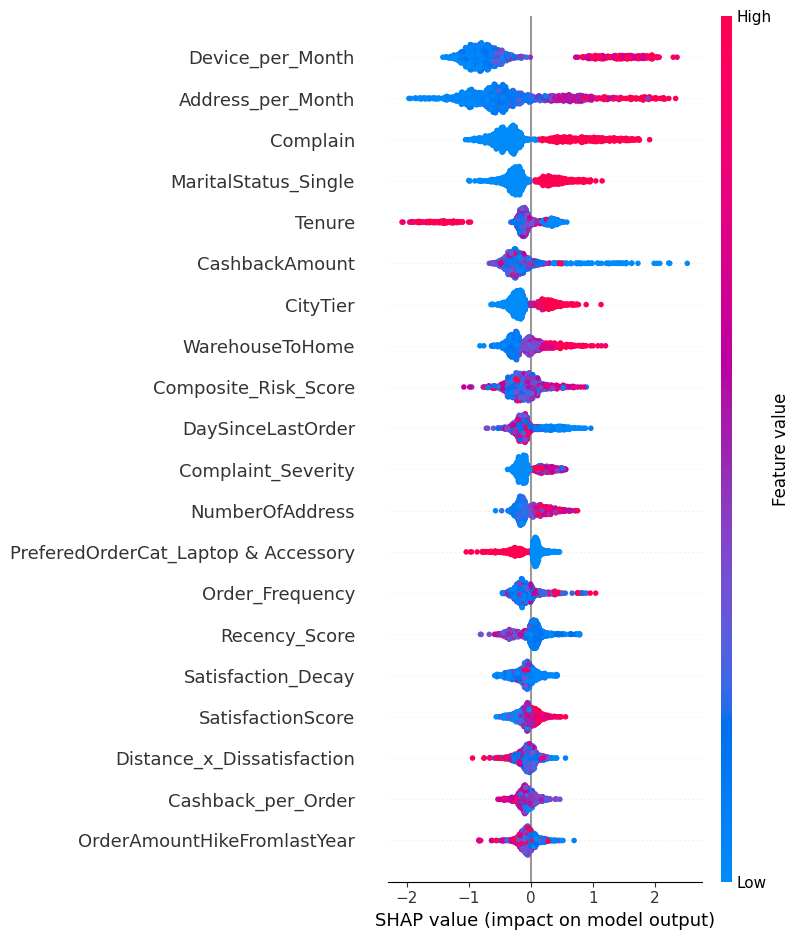

In [17]:
# ==============================
# SHAP summary plot
# ==============================
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=feature_names
)

In [ ]:
# ==============================
# Save model + preprocessing artifacts
# ==============================
import joblib
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_to_use = best_xgb   # or xgb_classifier

# Recompute predictions if needed
y_pred = model_to_use.predict(X_test)
y_proba = model_to_use.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

# Save preprocessing parts separately
joblib.dump(num_imputer_cls, "xgb_num_imputer.joblib")
joblib.dump(cat_imputer_cls, "xgb_cat_imputer.joblib")
joblib.dump(encoder, "xgb_encoder.joblib")
joblib.dump(scaler, "xgb_scaler.joblib")
joblib.dump(model_to_use, "xgb_model.joblib")

meta = {
    "target": "Churn",
    "raw_input_columns": X.columns.tolist(),
    "num_cols": numerical_cols,
    "cat_cols": categorical_cols,
    "metrics": {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "roc_auc": float(roc_auc_xgb)
    }
}

with open("xgb_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved artifacts:")
print(" - xgb_num_imputer.joblib")
print(" - xgb_cat_imputer.joblib")
print(" - xgb_encoder.joblib")
print(" - xgb_scaler.joblib")
print(" - xgb_model.joblib")
print(" - xgb_metadata.json")

Saved artifacts:
 - xgb_num_imputer.joblib
 - xgb_cat_imputer.joblib
 - xgb_encoder.joblib
 - xgb_scaler.joblib
 - xgb_model.joblib
 - xgb_metadata.json
